# RL-9 : RL offline — Behavior Cloning et erreur d'extrapolation

**Serie** : Reinforcement Learning | **Notebook** : 9/13 | **Duree estimee** : 50-55 min

**Prerequis** : notebook 5 (Q-learning, politiques epsilon-greedy) ; le notebook 8 (Dyna-Q) aide pour le labyrinthe de Sutton & Barto mais n'est pas indispensable.

## Objectifs pedagogiques

- Comprendre la difference entre RL **online** (l'agent interagit) et RL **offline** (un dataset fige de transitions, aucune interaction possible) ;
- Implementer le **Behavior Cloning** (BC) tabulaire et constater qu'il est plafonne par la qualite de la politique de comportement ;
- Mettre en evidence l'**erreur d'extrapolation** : pourquoi le Q-learning applique naivement a un dataset fige echoue, meme avec des donnees expertes ;
- Implementer une correction de type **BCQ** (contraindre le bootstrap au support du dataset) et observer le **stitching** : extraire une politique quasi optimale de donnees mediocres ;
- Relier ces idees aux methodes modernes (BCQ, CQL) et a l'alignement des LLM (RLHF, DPO).

## Plan

1. Du RL online au RL offline
2. Fabriquer les datasets : trois politiques de comportement
3. Behavior Cloning
4. Q-learning offline naif : l'erreur d'extrapolation
5. Contraindre au support du dataset : BCQ-lite
6. Du tabulaire au deep : BCQ, CQL et le pont vers RLHF/DPO
7. Exercices

## 1. Du RL online au RL offline

Tous les algorithmes vus jusqu'ici (Q-learning, DQN, policy gradient, Dyna-Q) sont **online** : l'agent choisit ses actions, observe les consequences, et corrige. Cette boucle d'essai-erreur est un luxe. En robotique, en sante, en conduite autonome ou en finance, laisser une politique non entrainee explorer librement est couteux, voire dangereux. En revanche, on dispose souvent de **journaux d'interactions passees** : trajectoires d'un operateur humain, logs d'un ancien controleur, historique de decisions cliniques.

Le **RL offline** (ou *batch RL*) pose la question : peut-on apprendre une bonne politique **uniquement** a partir d'un dataset fige $\mathcal{D} = \{(s_i, a_i, r_i, s'_i)\}$, collecte par une **politique de comportement** $\pi_\beta$ inconnue, sans jamais interagir avec l'environnement pendant l'apprentissage ?

Deux familles de reponses naives, deux echecs instructifs :

- **Imiter** : reproduire l'action majoritaire du dataset dans chaque etat (*Behavior Cloning*). Simple, mais on ne peut pas depasser $\pi_\beta$ — si les donnees sont mediocres, la copie l'est aussi.
- **Faire du Q-learning sur le dataset** : apres tout, le Q-learning est *off-policy*, il devrait digerer des donnees venues d'ailleurs. C'est vrai en apparence seulement : sans nouvelles interactions pour corriger les illusions, le $\max_a Q(s', a)$ bootstrape sur des actions **jamais observees** et l'erreur s'auto-amplifie. C'est l'**erreur d'extrapolation** (Fujimoto et al., 2019), que nous allons reproduire pas a pas.

Nous travaillons en tabulaire sur le labyrinthe 6x9 de Sutton & Barto (fig. 8.2) — le meme que le notebook 8 — avec une convention de recompense importante pour la suite : **-1 par pas, 0 en atteignant le but**. Maximiser le retour = minimiser la longueur du chemin, et surtout l'initialisation $Q = 0$ devient **optimiste** : une action jamais essayee semble meilleure que la realite. Retenez ce detail, c'est le carburant de l'erreur d'extrapolation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
ALPHA, GAMMA, EPSILON = 0.5, 0.95, 0.1
MAX_STEPS = 200          # troncature des episodes (echec = retour -200)

ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]   # haut, bas, gauche, droite
ACTION_NAMES = ["haut", "bas", "gauche", "droite"]

print(f"NumPy {np.__version__} — graine {SEED}")

NumPy 2.2.6 — graine 42


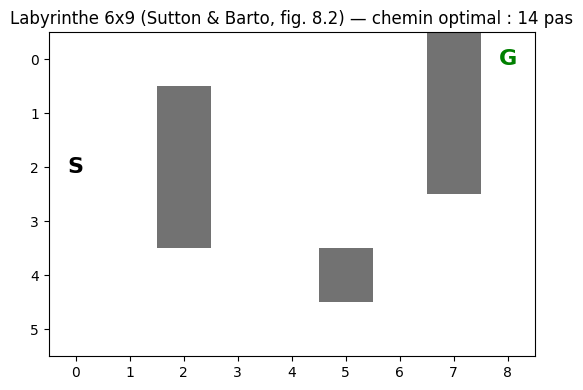

54 etats x 4 actions = 216 paires (s, a)


In [2]:
class Maze:
    """Labyrinthe 6x9 de Sutton & Barto (fig. 8.2).

    Recompense : -1 par pas, 0 en atteignant le but (episode termine).
    Le chemin optimal fait 14 pas, soit un retour de -13.
    """

    def __init__(self):
        self.height, self.width = 6, 9
        self.start = (2, 0)
        self.goal = (0, 8)
        self.obstacles = {(1, 2), (2, 2), (3, 2), (4, 5), (0, 7), (1, 7), (2, 7)}
        self.n_states = self.height * self.width
        self.n_actions = 4

    def idx(self, s):
        return s[0] * self.width + s[1]

    def reset(self):
        return self.start

    def step(self, s, a):
        dr, dc = ACTIONS[a]
        r2, c2 = s[0] + dr, s[1] + dc
        if not (0 <= r2 < self.height and 0 <= c2 < self.width) or (r2, c2) in self.obstacles:
            r2, c2 = s          # mur ou bord : on reste sur place
        s2 = (r2, c2)
        if s2 == self.goal:
            return s2, 0.0, True
        return s2, -1.0, False


env = Maze()

grid = np.zeros((env.height, env.width))
for (r, c) in env.obstacles:
    grid[r, c] = 1.0
fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(grid, cmap="Greys", vmin=0, vmax=1.6)
ax.text(env.start[1], env.start[0], "S", ha="center", va="center", fontsize=16, fontweight="bold")
ax.text(env.goal[1], env.goal[0], "G", ha="center", va="center", fontsize=16, fontweight="bold", color="green")
ax.set_xticks(range(env.width)); ax.set_yticks(range(env.height))
ax.set_title("Labyrinthe 6x9 (Sutton & Barto, fig. 8.2) — chemin optimal : 14 pas")
plt.tight_layout()
plt.show()

print(f"{env.n_states} etats x {env.n_actions} actions = {env.n_states * env.n_actions} paires (s, a)")

## 2. Fabriquer les datasets : trois politiques de comportement

En RL offline, le dataset est une donnee du probleme — mais pour etudier le phenomene en laboratoire, nous le fabriquons nous-memes. Nous entrainons d'abord **online** (Q-learning classique du notebook 5) deux politiques de qualites differentes, puis nous enregistrons leurs trajectoires comme de simples logs :

| Dataset | Politique de comportement | Analogue reel |
|---------|---------------------------|---------------|
| **expert** | Q-learning converge (300 episodes), $\epsilon = 0.1$ | demonstrations d'un operateur competent |
| **medium** | Q-learning interrompu (20 episodes), $\epsilon = 0.3$ | logs d'un ancien controleur mediocre |
| **random** | actions uniformes ($\epsilon = 1$) | exploration aveugle, donnees de capteurs bruts |

Pour chaque dataset nous mesurons deux choses : la **couverture** (fraction des paires $(s, a)$ presentes au moins une fois) et le **retour moyen** de la politique de comportement. Ces deux axes — qualite et couverture — sont orthogonaux, et chaque methode offline echoue sur un axe different.

In [3]:
def epsilon_greedy(Q, s_idx, n_actions, eps, rng):
    if rng.random() < eps:
        return rng.integers(n_actions)
    q = Q[s_idx]
    return rng.choice(np.flatnonzero(q == q.max()))


def q_learning_online(env, n_episodes, seed=0):
    """Q-learning online classique (notebook 5) — sert uniquement a fabriquer pi_beta."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    for _ in range(n_episodes):
        s = env.reset()
        for _ in range(MAX_STEPS):
            si = env.idx(s)
            a = epsilon_greedy(Q, si, env.n_actions, EPSILON, rng)
            s2, r, done = env.step(s, a)
            target = r if done else r + GAMMA * Q[env.idx(s2)].max()
            Q[si, a] += ALPHA * (target - Q[si, a])
            if done:
                break
            s = s2
    return Q


def evaluate_policy(env, policy, n_episodes=20, seed=123):
    """Deroule la politique deterministe policy[s] (action -1 = etat inconnu -> action aleatoire)."""
    rng = np.random.default_rng(seed)
    returns, successes = [], 0
    for _ in range(n_episodes):
        s, ret = env.reset(), 0.0
        for _ in range(MAX_STEPS):
            a = policy[env.idx(s)]
            if a < 0:
                a = rng.integers(env.n_actions)
            s, r, done = env.step(s, a)
            ret += r
            if done:
                successes += 1
                break
        returns.append(ret)
    return np.mean(returns), successes / n_episodes


Q_expert = q_learning_online(env, 300, seed=SEED)
Q_medium = q_learning_online(env, 20, seed=SEED)

ret_expert, _ = evaluate_policy(env, Q_expert.argmax(axis=1))
ret_medium, _ = evaluate_policy(env, Q_medium.argmax(axis=1))
print(f"Politique experte  (greedy, 300 ep online) : retour moyen {ret_expert:.1f}  (optimal = -13)")
print(f"Politique mediocre (greedy, 20 ep online)  : retour moyen {ret_medium:.1f}")

Politique experte  (greedy, 300 ep online) : retour moyen -13.0  (optimal = -13)
Politique mediocre (greedy, 20 ep online)  : retour moyen -200.0


In [4]:
def collect_dataset(env, Q_behavior, eps, n_episodes, seed=0):
    """Enregistre les transitions (s, a, r, s', done) de la politique epsilon-greedy(Q_behavior)."""
    rng = np.random.default_rng(seed)
    data, ep_returns = [], []
    for _ in range(n_episodes):
        s, ret = env.reset(), 0.0
        for _ in range(MAX_STEPS):
            si = env.idx(s)
            a = epsilon_greedy(Q_behavior, si, env.n_actions, eps, rng)
            s2, r, done = env.step(s, a)
            data.append((si, a, r, env.idx(s2), done))
            ret += r
            if done:
                break
            s = s2
        ep_returns.append(ret)
    return data, np.mean(ep_returns)


def coverage(env, data):
    pairs = {(s, a) for s, a, *_ in data}
    return len(pairs) / (env.n_states * env.n_actions)


datasets, behavior_returns = {}, {}
for name, (Qb, eps, seed) in {
    "expert": (Q_expert, 0.1, 1),
    "medium": (Q_medium, 0.3, 2),
    "random": (Q_expert, 1.0, 3),    # eps=1 : Q ignore, actions uniformes
}.items():
    datasets[name], behavior_returns[name] = collect_dataset(env, Qb, eps, n_episodes=50, seed=seed)

print(f"{'dataset':<8} {'transitions':>11} {'couverture':>11} {'retour comportement':>20}")
for name, d in datasets.items():
    print(f"{name:<8} {len(d):>11} {coverage(env, d):>10.0%} {behavior_returns[name]:>20.1f}")

dataset  transitions  couverture  retour comportement
expert           787        31%                -14.7
medium          7922        81%               -158.0
random          9735        85%               -194.6


**Lecture.** Les deux axes sont bien decorreles :

- Le dataset **expert** a un excellent retour mais une **couverture faible** (~30 %) : les trajectoires se concentrent sur le chemin optimal, l'immense majorite des paires $(s, a)$ n'est jamais observee.
- Le dataset **random** couvre ~85 % des paires, mais sa politique de comportement est catastrophique (la plupart des episodes n'atteignent jamais le but en 200 pas).
- Le dataset **medium** est mediocre sur les deux plans : couverture large mais trouee, comportement peu fiable.

C'est exactement la situation reelle du RL offline : *les bonnes donnees couvrent peu, les donnees couvrantes sont mauvaises*. Voyons comment chaque methode encaisse ce dilemme.

## 3. Behavior Cloning : imiter le dataset

La methode la plus simple ignore completement les recompenses : dans chaque etat, jouer l'**action majoritaire** du dataset. C'est la version tabulaire du *Behavior Cloning* — en deep, on entrainerait un classifieur $s \mapsto a$ par maximum de vraisemblance sur les paires $(s_i, a_i)$.

$$\pi_{BC}(s) = \arg\max_a \; \#\{i : s_i = s,\; a_i = a\}$$

Dans un etat jamais visite par le dataset, la politique n'a aucune information : nous tirons une action au hasard (c'est le *distribution shift* de l'imitation learning — des qu'on quitte les etats du dataset, on improvise).

In [5]:
def bc_policy(env, data):
    """Action majoritaire du dataset dans chaque etat (-1 si etat jamais visite)."""
    counts = np.zeros((env.n_states, env.n_actions))
    for s, a, *_ in data:
        counts[s, a] += 1
    policy = np.full(env.n_states, -1)
    visited = counts.sum(axis=1) > 0
    policy[visited] = counts[visited].argmax(axis=1)
    return policy


results_bc = {}
print(f"{'dataset':<8} {'retour BC':>10} {'succes':>8} {'(comportement)':>16}")
for name, d in datasets.items():
    ret, sr = evaluate_policy(env, bc_policy(env, d))
    results_bc[name] = ret
    print(f"{name:<8} {ret:>10.1f} {sr:>7.0%} {behavior_returns[name]:>16.1f}")

dataset   retour BC   succes   (comportement)
expert        -13.0    100%            -14.7
medium       -200.0      0%           -158.0
random       -200.0      0%           -194.6


**Le plafond de verre de l'imitation.** Sur les donnees expertes, BC est imbattable : l'action majoritaire dans chaque etat du chemin est l'action experte (le bruit $\epsilon$ est minoritaire), et le clone atteint le retour optimal. Mais sur **medium** et **random**, BC reproduit fidelement... une politique qui ne marche pas. L'imitation **filtre le bruit, pas la mediocrite** : elle ne peut pas depasser $\pi_\beta$, car elle n'utilise jamais les recompenses.

En pratique, BC reste un *baseline* redoutable quand les demonstrations sont bonnes (c'est le coeur du *fine-tuning supervise* des LLM). Ses limites — accumulation d'erreurs des qu'on sort de la distribution — sont l'objet de DAgger (Ross et al., 2011), qui re-sollicite l'expert sur les etats visites par le clone... ce qui exige une interaction, donc n'est plus offline.

Pour faire mieux que $\pi_\beta$, il faut exploiter les recompenses. Le candidat naturel est le Q-learning.

## 4. Q-learning offline naif : l'erreur d'extrapolation

Le Q-learning est *off-policy* : sa cible $r + \gamma \max_{a'} Q(s', a')$ ne depend pas de la politique qui a produit la transition. Il est donc tentant de le faire tourner directement sur le dataset, en rejouant les transitions en boucle (comme un replay buffer fige, sans jamais y ajouter de nouvelles experiences) :

$$Q(s, a) \leftarrow Q(s, a) + \alpha\,\big[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\big] \qquad (s, a, r, s') \sim \mathcal{D}$$

Le piege est dans le $\max_{a'}$ : il porte sur **toutes** les actions, y compris celles **jamais observees en $s'$**. Pour ces actions fantomes, $Q(s', a')$ garde sa valeur d'initialisation $0$ — qui, avec notre recompense de $-1$ par pas, est **optimiste** (la vraie valeur est negative partout sauf au but). Le bootstrap recopie alors cet optimisme : chaque cible vaut $-1 + \gamma \cdot 0 \approx -1$, toutes les valeurs s'ecrasent vers $-1$, et la politique greedy prefere systematiquement les actions inconnues aux actions documentees. En ligne, l'agent essaierait ces actions, serait decu, et corrigerait. **Offline, rien ne vient jamais corriger l'illusion.**

In [6]:
def offline_q(env, data, n_passes=300, constrain=False, seed=0, alpha=0.1):
    """Q-learning sur dataset fige.

    constrain=False : cible max sur TOUTES les actions (naif).
    constrain=True  : cible max restreinte aux actions observees en s' (BCQ-lite),
                      et politique greedy restreinte aux actions observees en s.
    """
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    seen = [set() for _ in range(env.n_states)]
    for s, a, *_ in data:
        seen[s].add(a)

    for _ in range(n_passes):
        for i in rng.permutation(len(data)):
            s, a, r, s2, done = data[i]
            if done:
                target = r
            elif constrain:
                acts = list(seen[s2])
                target = r + GAMMA * (max(Q[s2, aa] for aa in acts) if acts else 0.0)
            else:
                target = r + GAMMA * Q[s2].max()
            Q[s, a] += alpha * (target - Q[s, a])

    policy = np.full(env.n_states, -1)
    for s in range(env.n_states):
        if seen[s]:
            if constrain:
                acts = list(seen[s])
                policy[s] = acts[int(np.argmax([Q[s, aa] for aa in acts]))]
            else:
                policy[s] = Q[s].argmax()
    return Q, policy


results_naive = {}
print(f"{'dataset':<8} {'retour Q naif':>14} {'succes':>8} {'(BC)':>8}")
for name, d in datasets.items():
    _, pol = offline_q(env, d, constrain=False)
    ret, sr = evaluate_policy(env, pol)
    results_naive[name] = ret
    print(f"{name:<8} {ret:>14.1f} {sr:>7.0%} {results_bc[name]:>8.1f}")

dataset   retour Q naif   succes     (BC)


expert           -200.0      0%    -13.0


medium           -200.0      0%   -200.0


random            -13.0    100%   -200.0


**Un echec spectaculaire — et un succes revelateur.** Sur les donnees **expertes**, le Q-learning naif s'effondre (retour $-200$, 0 % de succes) alors que le simple BC etait optimal : utiliser les recompenses a *degrade* le resultat ! Sur **random**, en revanche, le naif retrouve la politique optimale. L'explication tient en un mot : **couverture**. Avec ~85 % des paires $(s, a)$ observees, presque aucune action fantome ne subsiste, et le Q-learning offline redevient du Q-learning ordinaire. L'erreur d'extrapolation n'est pas une fatalite du offline : c'est une maladie des **trous du dataset**, que le $\max$ s'empresse d'exploiter.

Mesurons l'ampleur du phenomene sur le dataset expert.

Etats visites par le dataset expert : 35
... dont la politique greedy naive choisit une action JAMAIS observee : 33 (94%)


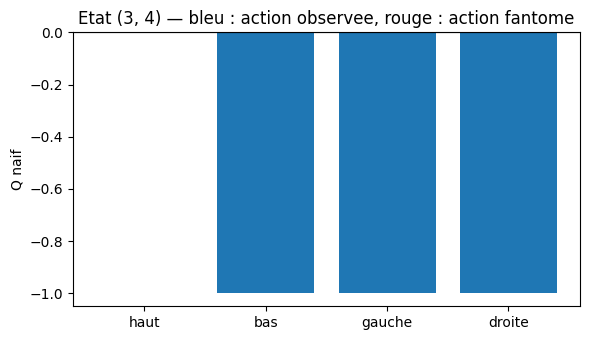

Q naif en (3, 4) : [ 0. -1. -1. -1.] — actions observees : ['bas', 'gauche', 'droite']


In [7]:
d_exp = datasets["expert"]
Q_naive, _ = offline_q(env, d_exp, constrain=False)
seen_exp = [set() for _ in range(env.n_states)]
for s, a, *_ in d_exp:
    seen_exp[s].add(a)

visited = [s for s in range(env.n_states) if seen_exp[s]]
greedy_unseen = sum(1 for s in visited if int(Q_naive[s].argmax()) not in seen_exp[s])
print(f"Etats visites par le dataset expert : {len(visited)}")
print(f"... dont la politique greedy naive choisit une action JAMAIS observee : "
      f"{greedy_unseen} ({greedy_unseen / len(visited):.0%})")

# Zoom sur un etat du chemin optimal : (3, 4)
s_zoom = env.idx((3, 4))
obs = sorted(int(a) for a in seen_exp[s_zoom])
colors = ["tab:blue" if a in obs else "tab:red" for a in range(4)]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(ACTION_NAMES, Q_naive[s_zoom], color=colors)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Q naif")
ax.set_title("Etat (3, 4) — bleu : action observee, rouge : action fantome")
plt.tight_layout()
plt.show()
print(f"Q naif en (3, 4) : {np.round(Q_naive[s_zoom], 2)} — actions observees : {[ACTION_NAMES[a] for a in obs]}")

La figure resume toute la pathologie : en $(3, 4)$, l'action « haut » n'apparait nulle part dans le dataset, son $Q$ est reste a l'initialisation $0$ — strictement au-dessus des actions documentees, toutes ecrasees vers $\approx -1$ par le bootstrap contamine. La politique greedy choisit donc l'action fantome dans **~94 % des etats visites** : elle ne suit jamais le chemin expert pourtant present sous ses yeux. Notez l'effet boule de neige : l'optimisme des actions fantomes ($Q = 0$) remonte dans les cibles $r + \gamma \max Q(s')$ des etats voisins, qui paraissent a leur tour meilleurs qu'ils ne sont. En deep RL, ou $Q$ est un reseau qui *generalise* aux actions non vues, le phenomene est encore plus violent — les valeurs divergent positivement (Fujimoto et al., 2019, fig. 1).

## 5. Contraindre au support du dataset : BCQ-lite

Le diagnostic dicte le remede : interdire au $\max$ de regarder les actions fantomes. On restreint le bootstrap **au support du dataset** :

$$Q(s, a) \leftarrow Q(s, a) + \alpha\,\Big[r + \gamma \max_{a' \,\in\, \mathcal{A}_\mathcal{D}(s')} Q(s', a') - Q(s, a)\Big]$$

ou $\mathcal{A}_\mathcal{D}(s') = \{a' : (s', a') \in \mathcal{D}\}$ est l'ensemble des actions effectivement observees en $s'$. La politique finale est elle aussi restreinte aux actions observees. C'est la version tabulaire de **BCQ** (*Batch-Constrained deep Q-learning*, Fujimoto et al., 2019) — en continu, un modele generatif estime $\pi_\beta(a|s)$ et le $\max$ ne porte que sur des actions plausibles sous le comportement.

L'enjeu : garder la capacite du Q-learning a **recombiner** des bouts de trajectoires (ce que BC ne sait pas faire), sans son optimisme hors support.

In [8]:
results_bcq = {}
print(f"{'dataset':<8} {'retour BCQ-lite':>16} {'succes':>8} {'(comportement)':>16}")
for name, d in datasets.items():
    _, pol = offline_q(env, d, constrain=True)
    ret, sr = evaluate_policy(env, pol)
    results_bcq[name] = ret
    print(f"{name:<8} {ret:>16.1f} {sr:>7.0%} {behavior_returns[name]:>16.1f}")

dataset   retour BCQ-lite   succes   (comportement)


expert              -13.0    100%            -14.7


medium              -13.0    100%           -158.0


random              -13.0    100%           -194.6


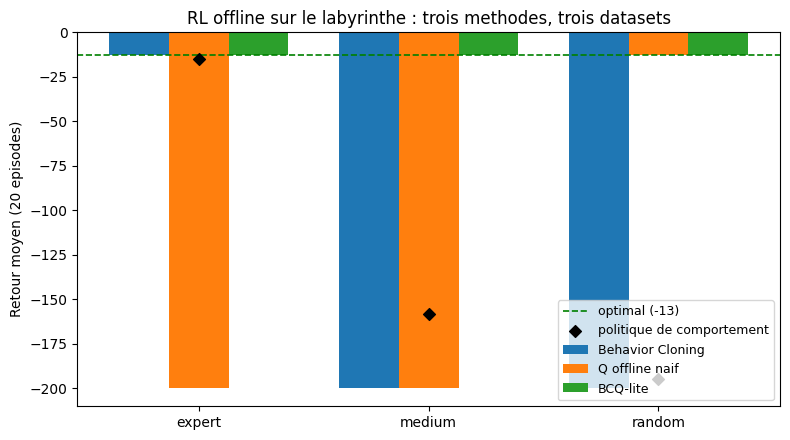

In [9]:
methods = {"Behavior Cloning": results_bc, "Q offline naif": results_naive, "BCQ-lite": results_bcq}
names = list(datasets.keys())
x = np.arange(len(names))
width = 0.26

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, (label, res) in enumerate(methods.items()):
    ax.bar(x + (i - 1) * width, [res[n] for n in names], width, label=label)
ax.axhline(-13, color="green", ls="--", lw=1.2, label="optimal (-13)")
ax.scatter(x, [behavior_returns[n] for n in names], color="black", marker="D", zorder=5,
           label="politique de comportement")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("Retour moyen (20 episodes)")
ax.set_title("RL offline sur le labyrinthe : trois methodes, trois datasets")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

**Lecture du tableau final.**

| Dataset | Comportement | BC | Q naif | BCQ-lite |
|---------|-------------:|----:|-------:|---------:|
| expert  | $\approx -15$ | $-13$ | $-200$ | $-13$ |
| medium  | $\approx -150$ | $-200$ | $-200$ | $-13$ |
| random  | $\approx -190$ | $-200$ | $-13$ | $-13$ |

- **BCQ-lite gagne sur les trois datasets** : il egale BC quand les donnees sont expertes, et il egale le Q-learning quand la couverture est totale. La contrainte de support ne coute rien quand elle est inutile.
- La ligne **medium** est la plus importante : la politique de comportement rate le but une fois sur deux (retour $\approx -150$), BC la copie et echoue, le naif delire — mais BCQ-lite extrait un chemin **optimal** ($-13$). C'est le **stitching** : le dataset contient, eparpilles dans des episodes differents, tous les troncons du bon chemin ; la programmation dynamique les recoud, ce que l'imitation pure ne peut pas faire.
- Le RL offline qui fonctionne se resume ainsi : *etre aussi ambitieux que le Q-learning a l'interieur du support des donnees, aussi humble que BC en dehors*.

## 6. Du tabulaire au deep : BCQ, CQL et le pont vers RLHF/DPO

En dimension reelle (etats continus, $Q$ approxime par un reseau), « l'ensemble des actions vues en $s'$ » n'existe plus litteralement — chaque etat est unique. Les methodes modernes traduisent la meme idee de trois facons :

- **BCQ** (Fujimoto et al., 2019) : un auto-encodeur variationnel modelise $\pi_\beta(a|s)$ ; le $\max$ ne porte que sur des actions echantillonnees de ce modele (contrainte de support *explicite*).
- **CQL** (*Conservative Q-Learning*, Kumar et al., 2020) : plutot que d'interdire, **penaliser** — un terme de regularisation pousse $Q$ vers le bas sur les actions hors distribution et vers le haut sur les actions du dataset. Le $Q$ appris est un *minorant* du vrai $Q$ : l'optimisme hors support devient du pessimisme (l'exercice 2 en construit la version tabulaire).
- **IQL, TD3+BC, Decision Transformer...** : la famille est riche, mais le principe est invariant — controler l'ecart entre la politique apprise et la politique de comportement.

**Le pont vers les LLM.** L'alignement d'un modele de langage est un probleme de RL offline deguise. Le *fine-tuning supervise* (SFT) est exactement du Behavior Cloning sur des demonstrations humaines. **RLHF** optimise ensuite une recompense apprise, avec une penalite KL qui force la politique a rester proche du modele de reference — le meme role que la contrainte de support de BCQ : sans elle, la politique exploite les zones ou le modele de recompense extrapole mal (*reward hacking*, le jumeau de notre erreur d'extrapolation). **DPO** (Rafailov et al., 2023) pousse la logique au bout : il elimine le RL et reecrit l'objectif RLHF comme une simple classification de preferences sous contrainte KL — de l'offline pur, sans interaction. La boucle est bouclee : les idees nees sur des labyrinthes 6x9 gouvernent aujourd'hui l'entrainement des plus grands modeles.

## 7. Exercices

Les trois exercices reutilisent les fonctions du notebook (`collect_dataset`, `bc_policy`, `offline_q`, `evaluate_policy`). Completez les cellules — elles doivent s'executer sans erreur meme incompletes.

### Exercice 1 — Combien de demonstrations faut-il ?

La qualite des methodes offline depend de la **taille** du dataset, pas seulement de sa qualite. Collectez des datasets experts de tailles croissantes et comparez BC et BCQ-lite : lequel est le plus econome en donnees ? A partir de combien d'episodes chacun devient-il fiable ?

In [10]:
# Exercice 1 — Ablation de la taille du dataset expert
# Etape 1 : pour n_ep dans `tailles`, collecter un dataset expert (Q_expert, eps=0.1, seed=1)
# Etape 2 : entrainer BC et l'offline Q contraint (constrain=True) sur chaque dataset
# Etape 3 : tracer les retours moyens en fonction de n_ep (2 courbes + ligne optimale -13)
# Indice : collect_dataset renvoie (data, retour_moyen) — ne garder que data

tailles = [1, 2, 5, 10, 50]
retours_bc_ex1 = None     # TODO etudiant : liste des retours BC, une valeur par taille
retours_bcq_ex1 = None    # TODO etudiant : liste des retours BCQ-lite

print("Exercice a completer")

Exercice a completer


### Exercice 2 — Penalite conservatrice (CQL-lite tabulaire)

CQL remplace l'interdiction stricte de BCQ par une **penalite** : les actions hors dataset gardent le droit d'exister, mais leur valeur est artificiellement abaissee. En tabulaire, la version la plus simple s'applique *apres* l'apprentissage naif :

$$Q_{pen}(s, a) = Q_{naif}(s, a) - \beta \cdot \mathbb{1}\big[(s, a) \notin \mathcal{D}\big]$$

Evaluez la politique greedy sur $Q_{pen}$ pour plusieurs $\beta$ sur le dataset **medium**. Que retrouve-t-on en $\beta = 0$ ? Vers quoi tend le comportement quand $\beta$ grandit ?

In [11]:
# Exercice 2 — CQL-lite : penaliser au lieu d'interdire
# Etape 1 : entrainer l'offline Q NAIF (constrain=False) sur datasets["medium"]
# Etape 2 : construire Q_pen = Q - beta * masque, ou masque[s, a] = 1 si (s, a) jamais vu
# Etape 3 : evaluer la politique greedy Q_pen.argmax(axis=1) pour chaque beta
# Indice : construire le masque a partir de {(s, a) for s, a, *_ in data}

betas = [0.0, 0.5, 2.0, 10.0]
retours_cql = None        # TODO etudiant : retour moyen pour chaque beta

print("Exercice a completer")

Exercice a completer


### Exercice 3 — Convergence : combien de passes sur le dataset ?

Un detail d'implementation qui n'en est pas un : `offline_q` rejoue le dataset `n_passes = 300` fois. Avec seulement 100 passes, BCQ-lite **echoue sur le dataset expert** alors que l'algorithme est correct. Reproduisez le phenomene et expliquez-le.

In [12]:
# Exercice 3 — Sensibilite au nombre de passes
# Etape 1 : pour n_passes dans `liste_passes`, entrainer offline_q(constrain=True)
#           sur datasets["expert"] et evaluer la politique
# Etape 2 : tracer le retour moyen en fonction de n_passes
# Etape 3 : afficher Q[env.idx(env.start)] pour n_passes=100 et 300 — quelle action
#           reste surevaluee trop longtemps, et pourquoi ?
# Indice : en (2, 0), l'action "gauche" cogne le mur (transition vers soi-meme).
#          Sa cible -1 + gamma * max Q(s) poursuit une cible mouvante : elle ne
#          converge qu'APRES les autres valeurs — un retard que 100 passes ne comblent pas.

liste_passes = [10, 50, 100, 300]
retours_passes = None     # TODO etudiant : retour moyen pour chaque n_passes

print("Exercice a completer")

Exercice a completer


## Conclusion

Ce notebook a parcouru le RL offline de bout en bout sur un probleme assez petit pour que chaque echec soit dissequable :

- Le **Behavior Cloning** est optimal quand les demonstrations le sont, et exactement aussi mauvais qu'elles sinon — il n'exploite pas les recompenses.
- Le **Q-learning naif sur dataset fige** echoue meme sur des donnees parfaites : le $\max$ bootstrape sur des actions jamais observees dont la valeur d'initialisation est optimiste, et aucune interaction ne vient corriger l'illusion. C'est l'**erreur d'extrapolation**, et elle disparait precisement quand la couverture devient quasi totale.
- La **contrainte de support** (BCQ-lite) reconcilie les deux mondes : aussi ambitieuse que la programmation dynamique dans le support des donnees, aussi prudente que l'imitation en dehors. Son fruit le plus precieux est le **stitching** — recoudre un chemin optimal a partir de trajectoires individuellement mediocres.

### Passerelles

- **Notebook 5** : le Q-learning online dont tout part ; **notebook 6** : le replay buffer de DQN est deja un mini-dataset offline (mais sans cesse rafraichi — c'est toute la difference) ;
- **Notebook 8** : Dyna-Q apprend un modele des transitions ; le RL offline *model-based* (MOPO, MOReL) suit la meme voie avec une penalite d'incertitude ;
- **[GenAI / FineTuning — FT-04 RLHF-DPO](../GenAI/FineTuning/FT-04-RLHF-DPO.ipynb)** : SFT = Behavior Cloning, RLHF = RL contraint par KL, DPO = preference learning offline — les notions de ce notebook, a l'echelle des LLM (pratique TRL/PEFT).
- **[GenAI / PostTraining](../GenAI/PostTraining/README.md)** : la chaine complete SFT -> RLHF -> [DPO (PT-03)](../GenAI/PostTraining/PT_03_dpo_direct_preference.ipynb) -> GRPO -> RLVR, ou la contrainte de support de BCQ devient la penalite KL de DPO. C'est la ou atterrit le pont esquisse ici.

### References

- Levine, Kumar, Tucker, Fu (2020), *Offline Reinforcement Learning: Tutorial, Review, and Perspectives on Open Problems*, arXiv:2005.01643
- Fujimoto, Meger, Precup (2019), *Off-Policy Deep Reinforcement Learning without Exploration* (BCQ), ICML
- Kumar, Zhou, Tucker, Levine (2020), *Conservative Q-Learning for Offline Reinforcement Learning* (CQL), NeurIPS
- Ross, Gordon, Bagnell (2011), *A Reduction of Imitation Learning and Structured Prediction to No-Regret Online Learning* (DAgger), AISTATS
- Rafailov et al. (2023), *Direct Preference Optimization: Your Language Model is Secretly a Reward Model*, NeurIPS
- Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, chap. 8 (labyrinthe fig. 8.2)